# Replicating the MGSR model on the authors' original dataset

Uses `master_scaled.csv`, the processed dataset published with James et al. (2023).
This is the check that the pipeline reproduces the paper's headline numbers when fed the paper's own data. The parallel notebook `extension_analysis.ipynb` runs the same code against my independently reconstructed dataset.

In [3]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('../new_data/master_scaled.csv', index_col=0)
print('Shape:', data.shape)
print('CCGs:', data.ccg.nunique())
print('Years:', sorted(data.year.unique()))
data.head()

Shape: (1465, 13)
CCGs: 73
Years: [np.int64(2018), np.int64(2019)]


,ccg,month,111_111_offered,111_111_answered,amb_sys_made,amb_sys_answered,gp_appt_available,ae_attendances_attendances,population,People,Places,Lives,year
0,00Q,Jan,406.655830,308.945095,310.561801,234.716187,4568.019766,1179.855246,14.8942,97.2,99.7,94.4,2018
1,00Q,Feb,349.933603,256.872981,261.756435,205.298797,3910.918344,1075.452189,14.8942,97.2,99.7,94.4,2018
2,00Q,Mar,413.247659,300.690725,303.676215,234.716187,4051.778545,1210.874032,14.8942,97.2,99.7,94.4,2018
3,00Q,Apr,349.608595,278.140171,264.973181,203.677924,3974.433001,1186.166427,14.8942,97.2,99.7,94.4,2018
4,00Q,May,361.100544,284.419492,294.361403,227.926437,4232.385761,1299.297713,14.8942,97.2,99.7,94.4,2018


In [5]:
capacity_features = ['gp_appt_available', '111_111_offered', 'amb_sys_answered']
pophealth_features = ['population', 'People', 'Places', 'Lives']
target = 'ae_attendances_attendances'

## Helper Functions

The population health variables (Population, People, Places, Lives) only change once a year, so the population health model works on one row per CCG per year rather than per month. `group_data` does that collapse, for each CCG-year it takes the fixed annual features and the mean of the twelve monthly ED attendance values.

`fit_ph` trains the population health model inside an inner cross-validation loop before the Level 1 combiner sees its predictions. Without this, the combiner would be trained on predictions the population health model had already seen the target for, which inflates the reported R².

In [6]:
def group_data(data, features):
    rows = []
    for (ccg, year), group in data.groupby(['ccg', 'year']):
        row = {'ccg': ccg, 'year': year}
        for f in features:
            row[f] = group[f].unique()[0]
        row[target] = group[target].mean()
        rows.append(row)
    return pd.DataFrame(rows)

def fit_ph(train_data, features, model):
    grouped = group_data(train_data, features)
    X_g, y_g = grouped[features], grouped[target]
    cv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
    results = pd.DataFrame()
    for tr, te in cv.split(X_g, y_g):
        model.fit(X_g.iloc[tr], y_g.iloc[tr])
        test = grouped.iloc[te].copy()
        test['ae_predicted'] = model.predict(X_g.iloc[te])
        results = pd.concat([results, test], ignore_index=True)
    train_data = train_data.merge(results[['ccg','year','ae_predicted']], on=['ccg','year'], how='left')
    return train_data

grouped = group_data(data, pophealth_features)
print('Grouped rows:', len(grouped))

Grouped rows: 132


## Capacity model (Level 0a)

Random Forest with `max_depth=5` and `n_estimators=6` — the paper's settings. Paper reports R² = 0.41.

In [21]:
rf_cap = RandomForestRegressor(max_depth=5, n_estimators=6, random_state=0)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=1)

scores = []
for tr, te in cv.split(data):
    rf_cap.fit(data[capacity_features].iloc[tr], data[target].iloc[tr])
    scores.append(rf_cap.score(data[capacity_features].iloc[te], data[target].iloc[te]))

print(f'Capacity RF baseline R2 = {np.mean(scores):.4f} +/- {np.std(scores):.4f}')
print('Paper reports: 0.41 +/- 0.02')

Capacity RF baseline R2 = 0.4112 +/- 0.0417
Paper reports: 0.41 +/- 0.02


## Population Health model (Level 0b)

Random Forest with `max_depth=4` and `n_estimators=2` are the settings the paper uses. Two trees is a tiny ensemble and the R² swings around a lot from one random split to the next, which is why the standard deviation below is so much larger than the paper's 0.05. Paper reports R² = 0.62.

In [7]:
rf_ph = RandomForestRegressor(max_depth=4, n_estimators=2, random_state=0)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=1)

scores = []
for tr, te in cv.split(grouped):
    rf_ph.fit(grouped[pophealth_features].iloc[tr], grouped[target].iloc[tr])
    scores.append(rf_ph.score(grouped[pophealth_features].iloc[te], grouped[target].iloc[te]))

print(f'Population Health RF baseline R2 = {np.mean(scores):.4f} +/- {np.std(scores):.4f}')
print('Paper reports: 0.62 +/- 0.22')

Population Health RF baseline R2 = 0.5470 +/- 0.2130
Paper reports: 0.62 +/- 0.22


## Combined MGSR (Level 0a + Level 0b into Level 1)

The full stack. A Random Forest on the capacity features and a Random Forest on the population health features each produce a prediction, and an ordinary least squares regression at Level 1 combines the two. Paper reports R² = 0.79.

In [8]:
rf1 = RandomForestRegressor(max_depth=5, n_estimators=6, random_state=0)
rf2 = RandomForestRegressor(max_depth=4, n_estimators=2, random_state=0)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=1)
scores_final = []

for train_idx, test_idx in cv.split(data):
    train_data = data.iloc[train_idx].copy()
    test_data = data.iloc[test_idx].copy()

    train_data = fit_ph(train_data, pophealth_features, rf2)
    rf1.fit(train_data[capacity_features], train_data[target])

    cap_train = rf1.predict(train_data[capacity_features])
    ph_train = train_data['ae_predicted']

    final = LinearRegression()
    final.fit(np.vstack([cap_train, ph_train]).T, train_data[target])

    cap_test = rf1.predict(test_data[capacity_features])
    grouped_all = group_data(data, pophealth_features)
    rf2.fit(grouped_all[pophealth_features], grouped_all[target])
    ph_test = rf2.predict(test_data[pophealth_features])

    score = final.score(np.vstack([cap_test, ph_test]).T, test_data[target])
    scores_final.append(score)

scores_final = np.array(scores_final)
print(f'Combined MGSR R2 = {scores_final.mean():.4f} +/- {scores_final.std():.4f}')
print('Paper reports: 0.79 +/- 0.02')

Combined MGSR R2 = 0.7976 +/- 0.0168
Paper reports: 0.79 +/- 0.02


## Permutation importance

Shuffling one variable at a time in the test set and seeing how far the combined model's R² drops. A big drop means the variable was carrying real information. This is the paper's Figure 4.

In [9]:
all_features = capacity_features + pophealth_features
rng = np.random.RandomState(42)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=1)
pi_scores = {f: [] for f in all_features}

for train_idx, test_idx in cv.split(data):
    train_data = data.iloc[train_idx].copy()
    test_data = data.iloc[test_idx].copy()

    train_data = fit_ph(train_data, pophealth_features, rf2)
    rf1.fit(train_data[capacity_features], train_data[target])

    cap_train = rf1.predict(train_data[capacity_features])
    ph_train = train_data['ae_predicted']
    final = LinearRegression()
    final.fit(np.vstack([cap_train, ph_train]).T, train_data[target])

    grouped_all = group_data(data, pophealth_features)
    rf2.fit(grouped_all[pophealth_features], grouped_all[target])

    def combined_predict(td):
        cap_pred = rf1.predict(td[capacity_features])
        ph_pred = rf2.predict(td[pophealth_features])
        return final.predict(np.vstack([cap_pred, ph_pred]).T)

    baseline_preds = combined_predict(test_data)
    baseline_r2 = r2_score(test_data[target], baseline_preds)

    for feat in all_features:
        td_perm = test_data.copy()
        td_perm[feat] = rng.permutation(td_perm[feat].values)
        perm_r2 = r2_score(test_data[target], combined_predict(td_perm))
        pi_scores[feat].append(baseline_r2 - perm_r2)

pi_df = pd.DataFrame(pi_scores)
pi_summary = pd.DataFrame({
    'mean_PI': pi_df.mean(),
    'std_PI': pi_df.std()
}).sort_values('mean_PI', ascending=False)

print(pi_summary.round(4))
print()
print('Paper values: Population 0.39, Lives 0.22, People 0.07, Ambulance 0.05, Places 0.04, 111 0.02, GP 0.01')

                   mean_PI  std_PI
population          0.2670  0.0383
Lives               0.1725  0.0268
amb_sys_answered    0.1537  0.0371
People              0.1015  0.0209
111_111_offered     0.0757  0.0153
Places              0.0343  0.0104
gp_appt_available   0.0274  0.0094

Paper values: Population 0.39, Lives 0.22, People 0.07, Ambulance 0.05, Places 0.04, 111 0.02, GP 0.01


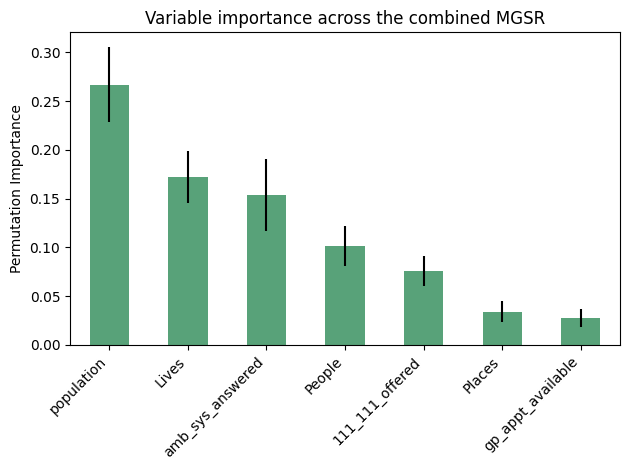

In [10]:
pi_summary['mean_PI'].plot(kind='bar', yerr=pi_summary['std_PI'], color='seagreen', alpha=0.8)
plt.ylabel('Permutation Importance')
plt.title('Variable importance across the combined MGSR')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Forecast accuracy

Training the whole stack on 2018 and predict monthly ED attendances for 2019. The paper's headline forecasting number is MAPE 3%.

In [11]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

train_2018 = data[data.year == 2018].copy()
test_2019 = data[data.year == 2019].copy()
print('Train rows:', len(train_2018), '| Test rows:', len(test_2019))

Train rows: 665 | Test rows: 800


In [12]:
rf1 = RandomForestRegressor(max_depth=5, n_estimators=6, random_state=0)
rf2 = RandomForestRegressor(max_depth=4, n_estimators=2, random_state=0)

rf1.fit(train_2018[capacity_features], train_2018[target])
grouped_2018 = group_data(train_2018, pophealth_features)
rf2.fit(grouped_2018[pophealth_features], grouped_2018[target])

cap_train = rf1.predict(train_2018[capacity_features])
ph_train = rf2.predict(train_2018[pophealth_features])
final = LinearRegression()
final.fit(np.vstack([cap_train, ph_train]).T, train_2018[target])

cap_test = rf1.predict(test_2019[capacity_features])
ph_test = rf2.predict(test_2019[pophealth_features])
test_2019['ae_predicted'] = final.predict(np.vstack([cap_test, ph_test]).T)

monthly = test_2019.groupby('month')[[target,'ae_predicted']].mean().reindex(month_order)
mape = (np.abs(monthly[target] - monthly['ae_predicted']) / monthly[target]).mean() * 100
r2 = r2_score(test_2019[target], test_2019['ae_predicted'])

print(monthly.round(1))
print(f'MAPE: {mape:.1f}% (paper reports 3%)')
print(f'R2: {r2:.3f}')

       ae_attendances_attendances  ae_predicted
month                                          
Jan                         499.2         504.2
Feb                         456.8         489.5
Mar                         497.5         474.0
Apr                         485.4         467.1
May                         492.0         468.8
Jun                         477.5         463.1
Jul                         516.1         482.3
Aug                         485.8         462.9
Sep                         481.9         470.7
Oct                         497.9         486.2
Nov                         485.4         474.3
Dec                         490.0         448.7
MAPE: 4.3% (paper reports 3%)
R2: 0.693


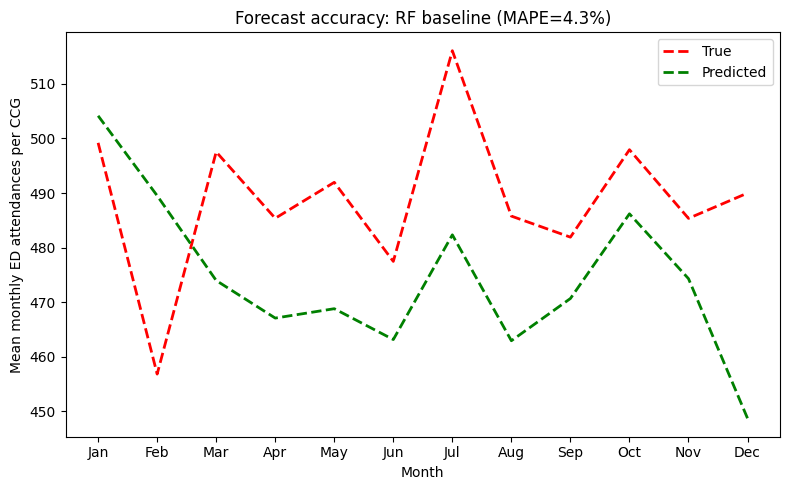

In [13]:
plt.figure(figsize=(8,5))
plt.plot(month_order, monthly[target], 'r--', label='True', linewidth=2)
plt.plot(month_order, monthly['ae_predicted'], 'g--', label='Predicted', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Mean monthly ED attendances per CCG')
plt.title(f'Forecast accuracy: RF baseline (MAPE={mape:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()

# Extension: alternative Level 0 models

Swapping the paper's Random Forests for XGBoost and Gradient Boosting, keeping everything else identical (same features, same cross-validation, same two-level stack).

## XGBoost as the capacity model

In [14]:
xgb_cap = XGBRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0, verbosity=0)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=1)
scores = []
for tr, te in cv.split(data):
    xgb_cap.fit(data[capacity_features].iloc[tr], data[target].iloc[tr])
    scores.append(xgb_cap.score(data[capacity_features].iloc[te], data[target].iloc[te]))

print(f'XGBoost Capacity R2 = {np.mean(scores):.4f} +/- {np.std(scores):.4f}')

XGBoost Capacity R2 = 0.4159 +/- 0.0468


## XGBoost as the population health model

In [15]:
grouped = group_data(data, pophealth_features)
xgb_ph = XGBRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0, verbosity=0)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=1)
scores = []
for tr, te in cv.split(grouped):
    xgb_ph.fit(grouped[pophealth_features].iloc[tr], grouped[target].iloc[tr])
    scores.append(xgb_ph.score(grouped[pophealth_features].iloc[te], grouped[target].iloc[te]))

print(f'XGBoost PopHealth R2 = {np.mean(scores):.4f} +/- {np.std(scores):.4f}')

XGBoost PopHealth R2 = 0.6186 +/- 0.1895


## Gradient Boosting as the population health model

In [16]:
grouped = group_data(data, pophealth_features)
gbr_ph = GradientBoostingRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=1)
scores = []
for tr, te in cv.split(grouped):
    gbr_ph.fit(grouped[pophealth_features].iloc[tr], grouped[target].iloc[tr])
    scores.append(gbr_ph.score(grouped[pophealth_features].iloc[te], grouped[target].iloc[te]))

print(f'GBR PopHealth R2 = {np.mean(scores):.4f} +/- {np.std(scores):.4f}')

GBR PopHealth R2 = 0.6682 +/- 0.1480


## Combined MGSR - XGBoost at both levels

In [17]:
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=1)
scores = []

for train_idx, test_idx in cv.split(data):
    train_data = data.iloc[train_idx].copy()
    test_data = data.iloc[test_idx].copy()

    cap = XGBRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0, verbosity=0)
    cap.fit(train_data[capacity_features], train_data[target])

    train_data = fit_ph(train_data, pophealth_features,
                        XGBRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0, verbosity=0))

    final = LinearRegression()
    final.fit(np.vstack([cap.predict(train_data[capacity_features]), train_data['ae_predicted']]).T, train_data[target])

    grouped_train = group_data(data.iloc[train_idx], pophealth_features)
    ph_test = XGBRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0, verbosity=0)
    ph_test.fit(grouped_train[pophealth_features], grouped_train[target])

    score = final.score(
        np.vstack([cap.predict(test_data[capacity_features]), ph_test.predict(test_data[pophealth_features])]).T,
        test_data[target])
    scores.append(score)

print(f'Combined MGSR (XGBoost+XGBoost) R2 = {np.mean(scores):.4f} +/- {np.std(scores):.4f}')

Combined MGSR (XGBoost+XGBoost) R2 = 0.8728 +/- 0.0149


## Combined MGSR - XGBoost capacity + Gradient Boosting population health

In [18]:
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=1)
scores = []

for train_idx, test_idx in cv.split(data):
    train_data = data.iloc[train_idx].copy()
    test_data = data.iloc[test_idx].copy()

    cap = XGBRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0, verbosity=0)
    cap.fit(train_data[capacity_features], train_data[target])

    train_data = fit_ph(train_data, pophealth_features,
                        GradientBoostingRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0))

    final = LinearRegression()
    final.fit(np.vstack([cap.predict(train_data[capacity_features]), train_data['ae_predicted']]).T, train_data[target])

    grouped_train = group_data(data.iloc[train_idx], pophealth_features)
    ph_test = GradientBoostingRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0)
    ph_test.fit(grouped_train[pophealth_features], grouped_train[target])

    score = final.score(
        np.vstack([cap.predict(test_data[capacity_features]), ph_test.predict(test_data[pophealth_features])]).T,
        test_data[target])
    scores.append(score)

print(f'Combined MGSR (XGBoost+GBR) R2 = {np.mean(scores):.4f} +/- {np.std(scores):.4f}')

Combined MGSR (XGBoost+GBR) R2 = 0.8996 +/- 0.0137


## Forecast accuracy with XGBoost + Gradient Boosting

Same 2018 → 2019 test as before, this time with the best-performing combination from above.

In [19]:
train_2018 = data[data.year == 2018].copy()
test_2019 = data[data.year == 2019].copy()

cap = XGBRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0, verbosity=0)
cap.fit(train_2018[capacity_features], train_2018[target])

grouped_2018 = group_data(train_2018, pophealth_features)
ph = GradientBoostingRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=0)
ph.fit(grouped_2018[pophealth_features], grouped_2018[target])

cap_train = cap.predict(train_2018[capacity_features])
ph_train = ph.predict(train_2018[pophealth_features])
final = LinearRegression()
final.fit(np.vstack([cap_train, ph_train]).T, train_2018[target])

cap_test = cap.predict(test_2019[capacity_features])
ph_test = ph.predict(test_2019[pophealth_features])
test_2019['ae_predicted'] = final.predict(np.vstack([cap_test, ph_test]).T)

monthly = test_2019.groupby('month')[[target,'ae_predicted']].mean().reindex(month_order)
mape = (np.abs(monthly[target] - monthly['ae_predicted']) / monthly[target]).mean() * 100
r2 = r2_score(test_2019[target], test_2019['ae_predicted'])

print(f'XGBoost+GBR Forecast: MAPE = {mape:.1f}%, R2 = {r2:.3f}')

XGBoost+GBR Forecast: MAPE = 3.5%, R2 = 0.844


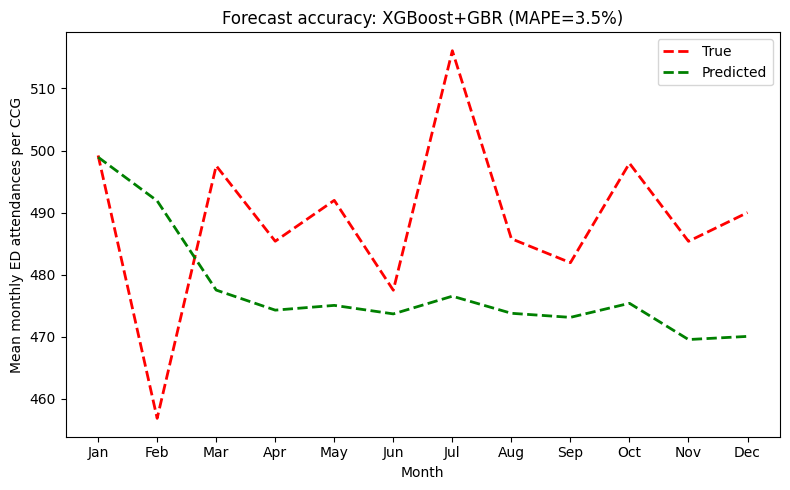

In [20]:
plt.figure(figsize=(8,5))
plt.plot(month_order, monthly[target], 'r--', label='True', linewidth=2)
plt.plot(month_order, monthly['ae_predicted'], 'g--', label='Predicted', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Mean monthly ED attendances per CCG')
plt.title(f'Forecast accuracy: XGBoost+GBR (MAPE={mape:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()